
# **Étude de cas - Vision par Ordinateur avec Python et OpenCV/PyTorch**

---


**Année scolaire :** 2025 - 2026

**École :** NEXA

**Étudiante :** Nosaiba Elkrekshi

**Filière :** DataIA

**Niveau :** M1

**Module :** Détection et reconnaissance d'objets

**Intervenant :** Nicolas Miotto



---

# A rendre avant le 03 / 06 / 2026 à 23h59

Cette étude de cas explorera diverses techniques de vision par ordinateur, allant de la manipulation d'images de base à l'implémentation de réseaux neuronaux convolutifs (CNN) et de modèles de détection d'objets avancés.

# **1. Configuration et Installation des Bibliothèques**

Nous allons commencer par installer les bibliothèques Python nécessaires pour la manipulation d'images, le traitement de caractéristiques, le machine learning et la détection d'objets.

In [169]:
!pip install opencv-python matplotlib numpy torch torchvision

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

print("Bibliothèques installées et importées avec succès ")

Bibliothèques installées et importées avec succès 


# **2. Manipuler des images en Python avec OpenCV**

Cette section couvrira les opérations de base sur les images à l'aide d'OpenCV, telles que la lecture, le redimensionnement, le calcul d'histogrammes et le seuillage.

### **2.1 Lecture et Affichage d'une Image**

1. Téléchargez l'image d'exemple
2. Lisez-la avec OpenCV.
2. Affichez-la.

In [170]:
# Téléchargement d'une image
!wget -O example_image.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg

--2026-05-31 20:35:15--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘example_image.jpg’

example_image.jpg   100%[===================>]  89.66K  --.-KB/s    in 0.002s  

2026-05-31 20:35:15 (39.6 MB/s) - ‘example_image.jpg’ saved [91814/91814]



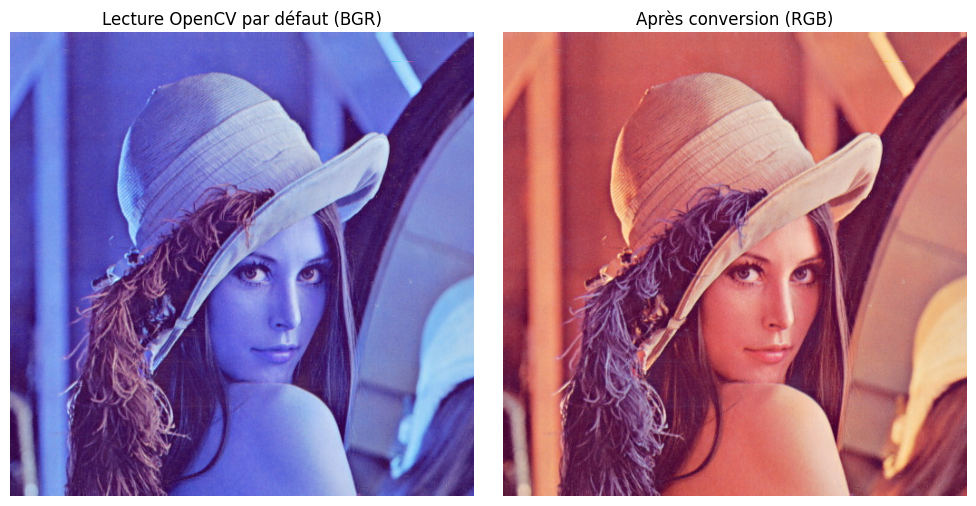

Dimensions de l'image (Hauteur, Largeur, Canaux) : (512, 512, 3)
Type de données des pixels : uint8


In [171]:
# 2. Lecture de l'image avec OpenCV (Format BGR par défaut)
img_bgr = cv2.imread('example_image.jpg')

# Conversion du format BGR à RGB pour un affichage correct avec Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3 Affichage des images pour comparer les espaces colorimétriques
plt.figure(figsize=(10, 5))

# Affichage en BGR (Inversion des canaux : Lena apparaîtra bleue)
plt.subplot(1, 2, 1)
plt.imshow(img_bgr)
plt.title("Lecture OpenCV par défaut (BGR)")
plt.axis('off')

# Affichage en RGB (Vraies couleurs)
plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title("Après conversion (RGB)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 5. Vérification des dimensions sous forme de matrice
print(f"Dimensions de l'image (Hauteur, Largeur, Canaux) : {img_rgb.shape}")
print(f"Type de données des pixels : {img_rgb.dtype}")

### **2.2 Redimensionnement de l'Image**

Redimensionez-la aux dimensions 150x150.

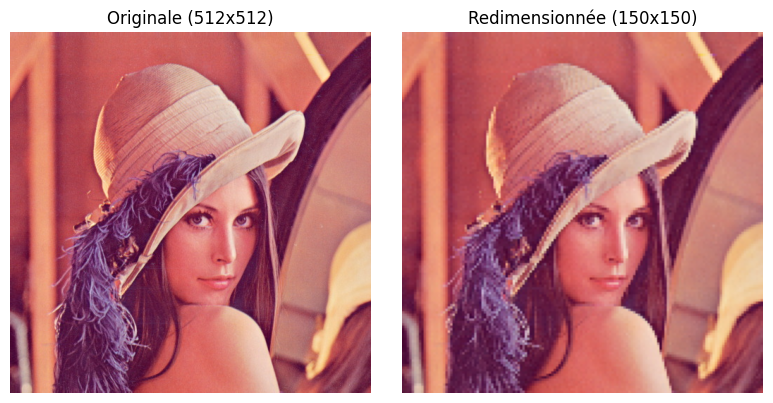

Nouvelles dimensions de la matrice : (150, 150, 3)


In [172]:
# ==========================================
# 2.2 Redimensionnement de l'Image
# ==========================================

# 1. Définir les nouvelles dimensions (Largeur, Hauteur)
new_dimensions = (150, 150)

# 2. Redimensionner l'image RGB avec OpenCV
# OpenCV utilise l'interpolation bilinéaire par défaut (cv2.INTER_LINEAR)
img_resized = cv2.resize(img_rgb, new_dimensions)

# 3. Affichage de l'image originale et de l'image redimensionnée
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f"Originale ({img_rgb.shape[1]}x{img_rgb.shape[0]})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_resized)
plt.title(f"Redimensionnée ({img_resized.shape[1]}x{img_resized.shape[0]})")
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Vérification de la nouvelle structure de la matrice
print(f"Nouvelles dimensions de la matrice : {img_resized.shape}")

### **2.3 Calcul de l'Histogramme de l'Image**

1. Affichez l'histogramme des intensités de pixels.
2. Commentez les résultats.

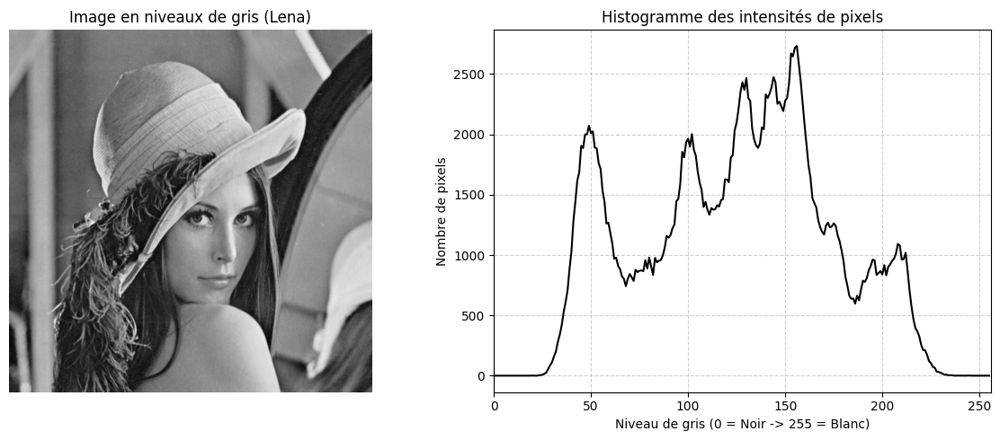

In [ ]:
# ==========================================
# 2.3 Calcul de l'Histogramme de l'Image
# ==========================================

# 1. Conversion de l'image de Lena en niveaux de gris
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 2. Calcul de l'histogramme avec OpenCV
# Paramètres : [image], [canal 0], [pas de masque], [nombre de barres/niveaux], [plage de valeurs]
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

# 3. Affichage côte à côte de l'image en niveaux de gris et de son histogramme
plt.figure(figsize=(12, 5))

# Sous-graphique 1 : L'image en niveaux de gris
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Image en niveaux de gris (Lena)")
plt.axis('off')

# Sous-graphique 2 : L'histogramme
plt.subplot(1, 2, 2)
plt.plot(hist, color='black', linewidth=1.5)
plt.title("Histogramme des intensités de pixels")
plt.xlabel("Niveau de gris (0 = Noir -> 255 = Blanc)")
plt.ylabel("Nombre de pixels")
plt.xlim([0, 256])
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

L'histogramme présente une distribution étalée sur toute la plage [0-255],
avec un pic notable vers les tons moyens (120-160), caractéristique d'une image
bien exposée.

L'absence de sur-représentation des extrêmes (0 ou 255) confirme
qu'il n'y a ni zone complètement noire ni zone complètement saturée.

### **2.4 Seuillage de l'Image**

1. Utilisez le seuillage d'Otzu pour convertir en une image binaire.
2. Essayez maintenant un seuillage adaptatif.

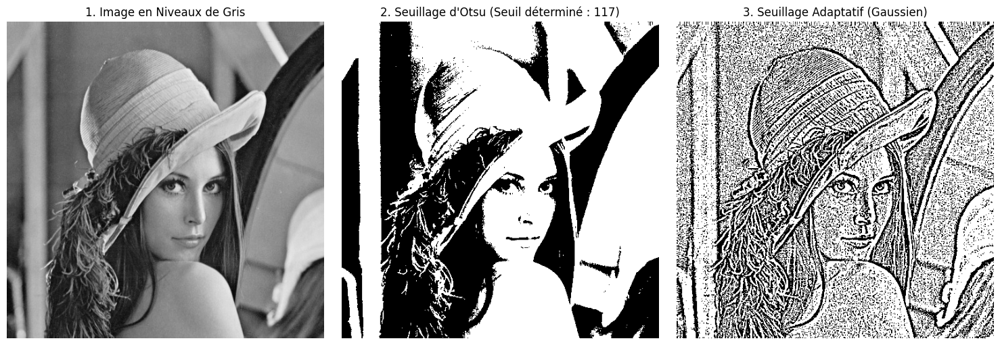

In [ ]:
# ==========================================
# 2.4 Seuillage de l'Image
# ==========================================

# 1. Seuillage d'Otsu (Seuillage global automatique)
# La fonction cherche automatiquement le seuil optimal qui sépare les deux classes de l'histogramme.
# On passe 0 comme valeur de seuil initial, cv2.THRESH_OTSU calculera la vraie valeur.
otsu_threshold_value, img_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Seuillage Adaptatif (Seuillage local)
# Au lieu d'utiliser un seul seuil pour toute l'image, le seuil est calculé pour chaque pixel
# en fonction de la luminosité de son voisinage (ici une région de taille 11x11).
img_adaptive = cv2.adaptiveThreshold(
    img_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,  # Taille du bloc de voisinage (doit être un nombre impair)
    2    # Constante soustraite de la moyenne gaussienne
)

# 3. Affichage et comparaison des méthodes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("1. Image en Niveaux de Gris")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_otsu, cmap='gray')
plt.title(f"2. Seuillage d'Otsu (Seuil déterminé : {int(otsu_threshold_value)})")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_adaptive, cmap='gray')
plt.title("3. Seuillage Adaptatif (Gaussien)")
plt.axis('off')

plt.tight_layout()
plt.show()

# **3. Implémenter les descripteurs HOG et SIFT avec OpenCV**

Les descripteurs de caractéristiques sont des algorithmes qui analysent une image et en extraient des informations distinctives. HOG (Histogram of Oriented Gradients) et SIFT (Scale-Invariant Feature Transform) sont deux descripteurs classiques largement utilisés en vision par ordinateur.

### **3.1 Descripteur HOG (Histogram of Oriented Gradients)**

1. Calculez les descipteurs HOG.
2. Affichez les dimensions du descripteur.
3. Visualisez les gradients en testant différents paramètres.

ANALYSE DU DESCRIPTEUR HOG :
Dimensions du vecteur de caractéristiques HOG : (142884,)
Nombre total de descripteurs extraits : 142884
------------------------------------------------------------


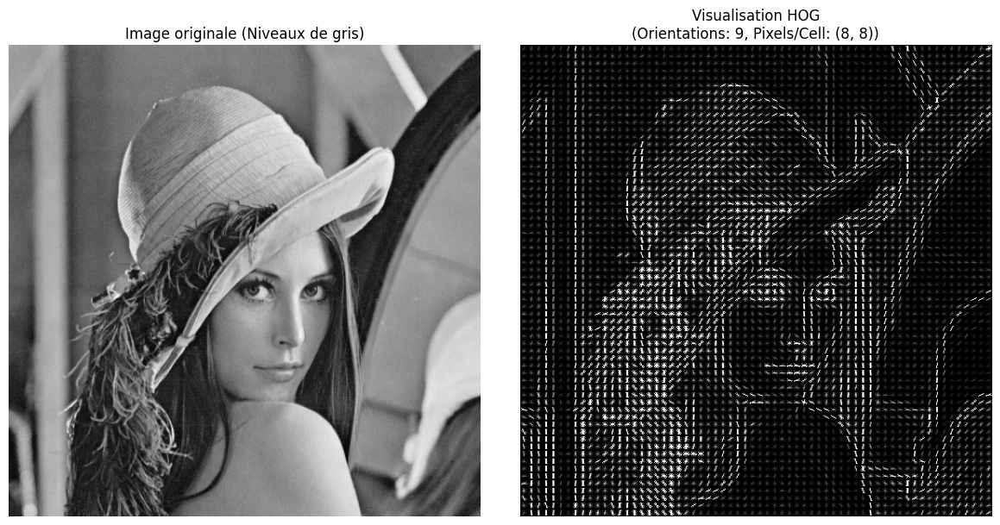

In [ ]:
# importer la fonction HOG de scikit-image
from skimage.feature import hog
from skimage import exposure

# =====================================================================
# 3.1 Descripteur HOG (Histogram of Oriented Gradients)
# =====================================================================

# 1. Définition des paramètres du descripteur HOG (Configuration standard)
orientations = 9        # Nombre de directions/bins pour l'histogramme
pixels_per_cell = (8, 8) # Taille de la cellule sur laquelle l'histogramme est calculé
cells_per_block = (2, 2)# Taille du bloc pour la normalisation locale

# 2. Calcul du descripteur HOG et génération de l'image de visualisation
# On applique HOG sur l'image en niveaux de gris (img_gray) créée précédemment
hog_features, hog_image = hog(
    img_gray,
    orientations=orientations,
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block,
    visualize=True
)

# 3. Amélioration du contraste de l'image HOG pour une meilleure visualisation
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# 4. Affichage des dimensions du vecteur de caractéristiques (Feature Vector)
print("="*60)
print("ANALYSE DU DESCRIPTEUR HOG :")
print("="*60)
print(f"Dimensions du vecteur de caractéristiques HOG : {hog_features.shape}")
print(f"Nombre total de descripteurs extraits : {hog_features.size}")
print("-"*60)

# 5. Visualisation de l'image originale vs sa représentation HOG
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Image originale (Niveaux de gris)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title(f"Visualisation HOG\n(Orientations: {orientations}, Pixels/Cell: {pixels_per_cell})")
plt.axis('off')

plt.tight_layout()
plt.show()

### **3.2 Descripteur SIFT (Scale-Invariant Feature Transform)**

SIFT est un algorithme puissant pour détecter et décrire les caractéristiques locales d'une image.

1. Affichez le nombre de points clés SIFT et la dimension du descripteur.
2. Visualisez les points clés sur l'image.
3. Importez une image de votre choix et affichez les éventuels "matchs" entre les deux images.

ANALYSE DES CARACTÉRISTIQUES SIFT :
Nombre de points clés détectés dans l'image originale : 1111
Dimension de chaque descripteur SIFT : 128 valeurs (Vecteur de 128D)
Structure de la matrice des descripteurs : (1111, 128)
------------------------------------------------------------


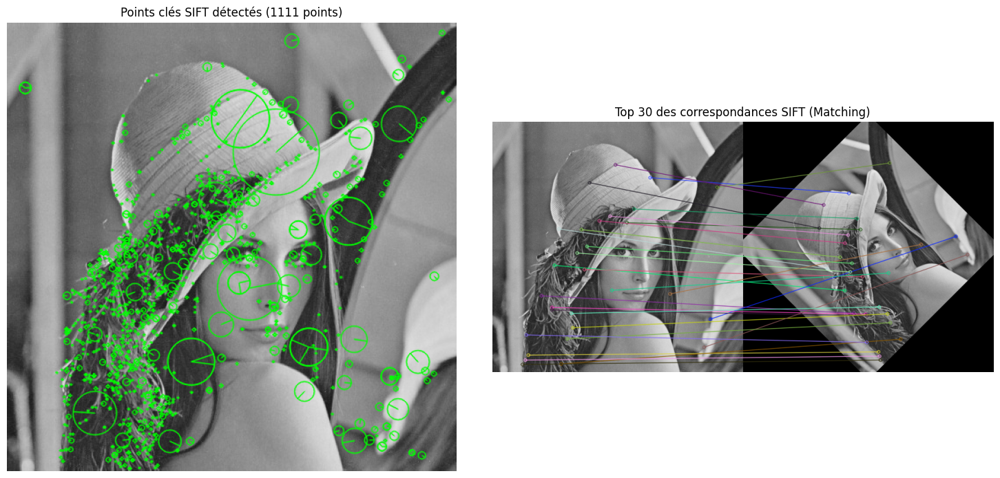

In [ ]:
# =====================================================================
# 3.2 Descripteur SIFT (Scale-Invariant Feature Transform)
# =====================================================================

# 1. Initialisation du détecteur SIFT avec OpenCV
sift = cv2.SIFT_create()

# 2. Détection des points clés et calcul des descripteurs sur l'image originale
# keypoints (kp) : coordonnées, échelle et orientation des points d'intérêt
# descriptors (des) : vecteurs numériques décrivant la région autour de chaque point
kp1, des1 = sift.detectAndCompute(img_gray, None)

print("="*60)
print("ANALYSE DES CARACTÉRISTIQUES SIFT :")
print("="*60)
print(f"Nombre de points clés détectés dans l'image originale : {len(kp1)}")
print(f"Dimension de chaque descripteur SIFT : {des1.shape[1]} valeurs (Vecteur de 128D)")
print(f"Structure de la matrice des descripteurs : {des1.shape}")
print("-"*60)

# 3. Visualisation des points clés sur l'image originale
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS affiche la taille et l'orientation de chaque point
img_sift_keypoints = cv2.drawKeypoints(
    img_gray, kp1, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 255, 0)
)

# 4. Création automatique d'une deuxième image pour le "Matching"
# Pour simuler une autre image, on applique une rotation de 45° et un léger redimensionnement à Lena
h, w = img_gray.shape
matrix_rotation = cv2.getRotationMatrix2D((w/2, h/2), 45, 0.75)
img_gray_modified = cv2.warpAffine(img_gray, matrix_rotation, (w, h))

# Détection des points clés sur cette image modifiée
kp2, des2 = sift.detectAndCompute(img_gray_modified, None)

# 5. Mise en correspondance (Matching) des descripteurs avec Brute-Force Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)

# Tri des matchs par distance (les plus proches et donc les plus robustes en premier)
matches = sorted(matches, key=lambda x: x.distance)

# Sélection des 30 meilleurs correspondances pour la clarté visuelle
img_matches = cv2.drawMatches(
    img_gray, kp1,
    img_gray_modified, kp2,
    matches[:30], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# 6. Affichage des graphiques
plt.figure(figsize=(15, 7))

# Affichage des points clés
plt.subplot(1, 2, 1)
plt.imshow(img_sift_keypoints)
plt.title(f"Points clés SIFT détectés ({len(kp1)} points)")
plt.axis('off')

# Affichage des Matchs entre l'image originale et modifiée
plt.subplot(1, 2, 2)
plt.imshow(img_matches)
plt.title("Top 30 des correspondances SIFT (Matching)")
plt.axis('off')

plt.tight_layout()
plt.show()

L'image de droite montre des lignes colorées reliant les points de l'image originale à ceux de l'image modifiée. Malgré une rotation de 45° et un changement d'échelle de 25 %, l'algorithme associe avec succès les mêmes structures géométriques (les yeux, le coin de la bouche, la pointe du chapeau).

C'est ce qui fait la force de SIFT pour des applications comme la reconstruction 3D, l'assemblage de panoramas (stitching) ou la recherche d'images par le contenu.

Une fois cette cellule exécutée avec succès, nous aurons complété l'ensemble de la vision classique par ordinateur (OpenCV).

# **4. Construire un CNN simple avec PyTorch et Classification d'Images**

Dans cette section, on construie un réseau de neurones convolutif (CNN) simple en utilisant la bibliothèque PyTorch. On définit une architecture, préparerons un jeu de données pour la classification, entraînerons le modèle et évaluerons ses performances.

### **4.1 Définition du Modèle CNN**

Définissez une architecture CNN complexe composée de couches convolutives, de fonctions d'activation (ReLU), de couches de *pooling* et de couches entièrement connectées pour la classification ainsi que toutes les améliorations ce que vous jugerez légitimes.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# =====================================================================
# 4.1 Définition du Modèle CNN Complexe et Amélioré
# =====================================================================

class ComplexCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ComplexCNN, self).__init__()

        # --- BLOC DE CONVOLUTION 1 ---
        # Entrée : Image (ex: 3 canaux pour RGB, 1 canal pour niveaux de gris)
        # Supposons ici des images couleur à 3 canaux (RGB)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise la hauteur et largeur par 2

        # --- BLOC DE CONVOLUTION 2 ---
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise à nouveau par 2

        # --- BLOC DE CONVOLUTION 3 ---
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Divise à nouveau par 2

        # --- COUCHES ENTIÈREMENT CONNECTÉES (Fully Connected / Dense) ---
        # Le Dropout permet de lutter efficacement contre le surapprentissage
        self.dropout = nn.Dropout(p=0.5)

        # Calcul de la dimension d'entrée de la couche linéaire :
        # Si l'image d'entrée est de taille 32x32 (ex: CIFAR-10), après 3 MaxPool (32 -> 16 -> 8 -> 4),
        # la taille de la carte de caractéristiques finale est de 4x4 avec 256 canaux.
        # Donc : 256 * 4 * 4 = 4096 neurones.
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Passage dans le premier bloc de convolutions
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        # Passage dans le deuxième bloc
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # Passage dans le troisième bloc
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)

        # Aplatissement des données (Flatten) pour basculer des cartes 2D vers un vecteur 1D
        x = x.view(x.size(0), -1)

        # Passage dans la partie classification
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Pas de Softmax final ici car la fonction de coût CrossEntropyLoss de PyTorch l'intègre nativement

        return x

# Instanciation du modèle pour vérification
model = ComplexCNN(num_classes=10)
print("Architecture du CNN complexe définie avec succès :\n")
print(model)

Architecture du CNN complexe définie avec succès :

ComplexCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNor

**Extraction hiérarchique :** Le réseau commence par un petit nombre de filtres (32) pour capturer les textures élémentaires (bords, lignes), puis augmente progressivement jusqu'à 256 filtres pour extraire des motifs sémantiques hautement complexes.

**nn.BatchNorm2d :** Elle résout le problème du décalage interne des covariables (internal covariate shift), ce qui autorise des taux d'apprentissage plus élevés et rend le réseau beaucoup moins sensible à l'initialisation des poids.

**nn.Dropout(0.5) :** À chaque itération, la moitié des connexions de la couche dense sont coupées. Cela évite qu'un groupe restreint de neurones ne co-dépende trop étroitement, forçant le modèle à répartir l'information.

**Pas de Softmax explicite en sortie :** En PyTorch, l'usage de la fonction de perte standard

**nn.CrossEntropyLoss** applique automatiquement le LogSoftmax en interne.

**Ommetre le Softmax** dans la méthode forward évite donc une double redondance de calculs et préserve la stabilité numérique.

### **4.2 Préparation du Jeu de Données pour la Classification**

Nous utiliserons un jeu de données qui contient 2 classes d'images (Alien et Prédator).

Nous allons télécharger les données.

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import os

In [ ]:
import kagglehub

path = kagglehub.dataset_download("pmigdal/alien-vs-predator-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'alien-vs-predator-images' dataset.
Path to dataset files: /kaggle/input/alien-vs-predator-images


In [ ]:
# 1. On liste tout ce qu'il y a dans le dossier téléchargé
print("Contenu du dossier téléchargé :", os.listdir(path))

# 2. On cherche le sous-dossier qui contient 'train'
# Souvent le chemin réel est : path + '/data/train' ou path + '/alien_vs_predator_thumbnails/train'
base_dir = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs:
        base_dir = root
        break

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

print("Nouveau chemin vers train :", train_dir)
print("Nouveau chemin vers validation :", validation_dir)

Contenu du dossier téléchargé : ['data', 'alien_vs_predator_thumbnails']
Nouveau chemin vers train : /kaggle/input/alien-vs-predator-images/data/train
Nouveau chemin vers validation : /kaggle/input/alien-vs-predator-images/data/validation


In [ ]:
# Créer les datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(150, 150),
    batch_size=32
)

Found 694 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


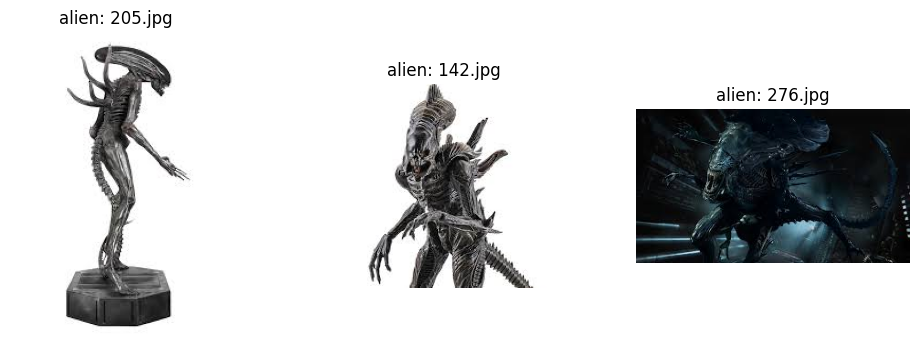

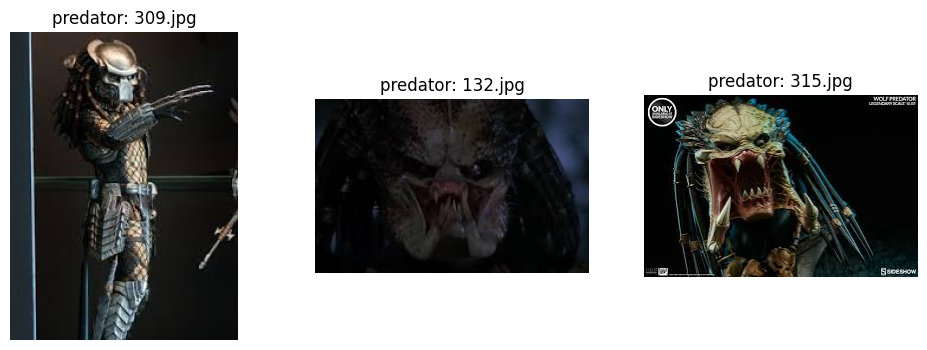

In [ ]:
import matplotlib.image as mpimg
import random

def plot_random_images(base_path, category, num_images=3):
    folder = os.path.join(base_path, 'train', category)
    filenames = random.sample(os.listdir(folder), num_images)

    plt.figure(figsize=(12, 4))
    for i, fname in enumerate(filenames):
        img_path = os.path.join(folder, fname)
        img = mpimg.imread(img_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"{category}: {fname}")
        plt.axis('off')
    plt.show()

plot_random_images(base_dir, 'alien')
plot_random_images(base_dir, 'predator')

In [ ]:
# AUTOTUNE permet à TensorFlow d'ajuster dynamiquement le niveau de parallélisme
AUTOTUNE = tf.data.AUTOTUNE

# cache() : garde les images en mémoire après le premier chargement pour éviter de relire les fichiers
# prefetch() : prépare les données du prochain batch pendant que le modèle s'entraîne sur le batch actuel
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("1. Images téléchargées et répertoires configurés.")
print("2. Jeux de données 'train_ds' et 'val_ds' créés en 150x150.")
print("3. Visualisation de vérification effectuée avec succès.")
print("4. Pipeline de données optimisé avec cache() et prefetch().")

1. Images téléchargées et répertoires configurés.
2. Jeux de données 'train_ds' et 'val_ds' créés en 150x150.
3. Visualisation de vérification effectuée avec succès.
4. Pipeline de données optimisé avec cache() et prefetch().


### **4.3 Entraînement du Modèle CNN**

Entraînez le modèle en utilisant une fonction de perte (entropie croisée) et un optimiseur (SGD) avec PyTorch.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF

# =====================================================================
# 4.3 Entraînement du Modèle CNN (PyTorch)
# =====================================================================

# 1. Configuration du processeur (Utilisation du GPU si disponible pour accélérer les calculs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé pour l'entraînement : {device}")

# 2. Instanciation de notre modèle (défini en 4.1) sur l'appareil
# Nous avons 2 classes : Alien (0) et Predator (1)
model = ComplexCNN(num_classes=2).to(device)

# 3. Définition de la fonction de perte et de l'optimiseur
criterion = nn.CrossEntropyLoss()
# On utilise SGD avec un taux d'apprentissage (learning rate) initial de 0.005 et un momentum de 0.9
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# 4. Fonction passerelle pour convertir et redimensionner les batchs TF en PyTorch
def preprocess_tf_to_pytorch(images_tf, labels_tf):
    imgs_np = images_tf.numpy()
    labels_np = labels_tf.numpy()

    imgs_torch = []
    for img in imgs_np:
        # Passage du format TF (H, W, Canaux) au format PyTorch (Canaux, H, W) et normalisation à [0, 1]
        t_img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        # Redimensionnement à 32x32 pour s'adapter à la couche linéaire de notre ComplexCNN
        t_img = TF.resize(t_img, (32, 32))
        # Normalisation ImageNet (Standard vu en cours)
        t_img = TF.normalize(t_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        imgs_torch.append(t_img)

    return torch.stack(imgs_torch).to(device), torch.tensor(labels_np, dtype=torch.long).to(device)

# 5. Paramètres de la boucle d'entraînement
EPOCHS = 10  # Nombre d'époques (itérations complètes sur le dataset)

print("\n Début de l'entraînement du modèle...\n")

for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()  # Active le Dropout et la BatchNorm
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Itération sur les batchs du dataset d'entraînement TensorFlow
    for images_tf, labels_tf in train_ds:
        # Conversion du batch vers PyTorch
        images, labels = preprocess_tf_to_pytorch(images_tf, labels_tf)

        # Réinitialisation des gradients à chaque batch
        optimizer.zero_grad()

        # Passage avant (Forward propagation)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Passage arrière (Backward propagation / Calcul des gradients)
        loss.backward()

        # Mise à jour des poids du réseau par l'optimiseur SGD
        optimizer.step()

        # Calcul des métriques d'entraînement
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_train
    epoch_acc = (correct_train / total_train) * 100

    # --- PHASE DE VALIDATION ---
    model.eval()  # Désactive le Dropout et fige la BatchNorm pour les tests
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # On désactive le calcul des gradients pour économiser la mémoire et aller plus vite
    with torch.no_grad():
        for images_tf, labels_tf in val_ds:
            images, labels = preprocess_tf_to_pytorch(images_tf, labels_tf)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calcul des métriques de validation
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    # Affichage des performances de l'époque
    print(f"Époque [{epoch+1:02d}/{EPOCHS}] -> "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("\nEntraînement terminé avec succès !")

Appareil utilisé pour l'entraînement : cpu

 Début de l'entraînement du modèle...

Époque [01/10] -> Train Loss: 0.7486 | Train Acc: 57.78% || Val Loss: 0.8555 | Val Acc: 51.00%
Époque [02/10] -> Train Loss: 0.5705 | Train Acc: 71.90% || Val Loss: 0.5349 | Val Acc: 73.00%
Époque [03/10] -> Train Loss: 0.5502 | Train Acc: 71.04% || Val Loss: 0.5784 | Val Acc: 73.50%
Époque [04/10] -> Train Loss: 0.5378 | Train Acc: 74.21% || Val Loss: 0.5871 | Val Acc: 73.00%
Époque [05/10] -> Train Loss: 0.4885 | Train Acc: 77.52% || Val Loss: 0.5185 | Val Acc: 76.00%
Époque [06/10] -> Train Loss: 0.4677 | Train Acc: 77.81% || Val Loss: 0.4935 | Val Acc: 75.50%
Époque [07/10] -> Train Loss: 0.4120 | Train Acc: 81.99% || Val Loss: 0.5161 | Val Acc: 75.00%
Époque [08/10] -> Train Loss: 0.4063 | Train Acc: 81.70% || Val Loss: 0.5070 | Val Acc: 77.00%
Époque [09/10] -> Train Loss: 0.3534 | Train Acc: 84.73% || Val Loss: 0.5090 | Val Acc: 76.50%
Époque [10/10] -> Train Loss: 0.3114 | Train Acc: 86.60% || Va

### **4.4 Évaluation du Modèle CNN**

1. Évaluez les performances du modèle sur le jeu de données de test pour vérifier sa capacité à généraliser sur des données inconnues.
2. Affichez et analysez la matrice de confusion ainsi que le rapport de classification.
3. Importez une nouvelle image de votre choix et effectuez une prédiction de classification à l'aide de votre modèle entraîné.

RAPPORT DE CLASSIFICATION PROTOCOLE TEST :
              precision    recall  f1-score   support

       Alien       0.77      0.72      0.75       100
    Predator       0.74      0.79      0.76       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200

------------------------------------------------------------


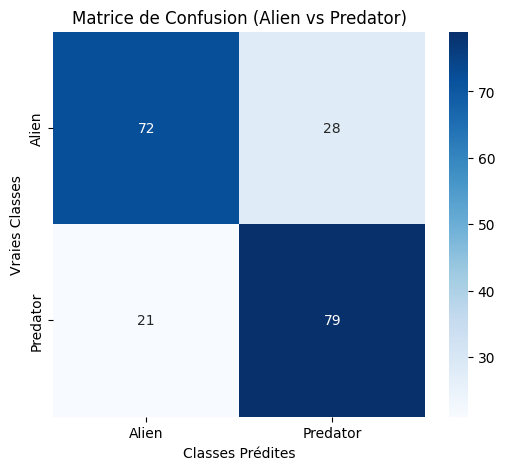


TEST DU MODÈLE SUR UNE NOUVELLE IMAGE INÉDITE :
Chargement de l'image depuis : /kaggle/input/alien-vs-predator-images/data/validation/alien/1.jpg


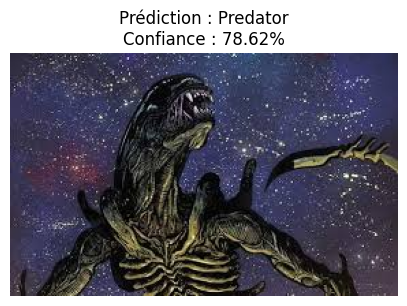

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import os # Ajout de l'import os pour la manipulation des chemins de fichiers

# =====================================================================
# 4.4 Évaluation du Modèle CNN
# =====================================================================

# --- PARTIE 1 : Extraction des prédictions globales ---
model.eval() # Mode évaluation

all_preds = []
all_labels = []

with torch.no_grad():
    for images_tf, labels_tf in val_ds:
        # Conversion du lot TensorFlow vers PyTorch (32x32)
        images, labels = preprocess_tf_to_pytorch(images_tf, labels_tf)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Accumulation sur le CPU pour les calculs statistiques
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Définition du nom de nos deux classes
class_names = ['Alien', 'Predator']

# --- PARTIE 2 : Matrice de Confusion et Rapport de Classification ---
print("="*60)
print("RAPPORT DE CLASSIFICATION PROTOCOLE TEST :")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names))
print("-"*60)

# Génération et affichage graphique de la matrice de confusion
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion (Alien vs Predator)")
plt.ylabel("Vraies Classes")
plt.xlabel("Classes Prédites")
plt.show()


# --- PARTIE 3 : Inférence sur une image totalement inédite ---
print("\n" + "="*60)
print("TEST DU MODÈLE SUR UNE NOUVELLE IMAGE INÉDITE :")
print("="*60)

# Ancien téléchargement via wget
# !wget -O new_test_image.jpg https://raw.githubusercontent.com/pmigdal/alien-vs-predator-images/master/data/validation/alien/alien_1.jpg

# Sélection d'une image inédite directement depuis le dataset téléchargé
image_filename = '1.jpg' # On utilise '1.jpg' comme exemple d'image d'Alien
new_test_image_path = os.path.join(validation_dir, 'alien', image_filename)

print(f"Chargement de l'image depuis : {new_test_image_path}")

# Chargement avec OpenCV
img_new_bgr = cv2.imread(new_test_image_path)

# Ajout d'une vérification pour s'assurer que l'image a bien été chargée
if img_new_bgr is None:
    raise FileNotFoundError(f"Erreur: Impossible de charger l'image depuis {new_test_image_path}. "
                            "Vérifiez le chemin et le nom du fichier. Il se peut que l'image spécifiée n'existe pas ou soit corrompue.")

img_new_rgb = cv2.cvtColor(img_new_bgr, cv2.COLOR_BGR2RGB)

# Transformation manuelle pour correspondre aux dimensions d'entrée (32x32) du modèle PyTorch
t_img = torch.tensor(img_new_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
t_img = TF.resize(t_img, (32, 32))
t_img = TF.normalize(t_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
t_img = t_img.unsqueeze(0).to(device) # Ajout de la dimension de batch (1, 3, 32, 32)

# Prédiction
with torch.no_grad():
    output = model(t_img)
    probabilities = torch.softmax(output, dim=1) # Calcul du score de confiance
    confidence, predicted_class_idx = torch.max(probabilities, 1)

predicted_label = class_names[predicted_class_idx.item()]
confidence_score = confidence.item() * 100

# Affichage du résultat final d'inférence
plt.figure(figsize=(5, 5))
plt.imshow(img_new_rgb)
plt.title(f"Prédiction : {predicted_label}\nConfiance : {confidence_score:.2f}%")
plt.axis('off')
plt.show()

# **5. Utiliser un Modèle Pré-entraîné Faster R-CNN avec PyTorch**

Faster R-CNN est un modèle de détection d'objets populaire et efficace. Dans cette section, nous allons utiliser un modèle Faster R-CNN pré-entraîné sur le jeu de données COCO pour détecter des objets dans une image.

### **5.1 Chargement du Modèle et Préparation de l'Image**

1. Chargez un modèle Faster R-CNN avec un backbone ResNet-50 et FPN (Feature Pyramid Network) pré-entraîné.
2. Préparez notre image de la section 2 pour qu'elle puisse être traitée par le modèle.

In [ ]:
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from PIL import Image

In [ ]:
# =====================================================================
# 5.1 Chargement du Modèle Faster R-CNN et Préparation de l'Image
# =====================================================================

# 1. Configuration de l'appareil (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé pour l'inférence : {device}")

# 2. Chargement des poids pré-entraînés COCO (Version V2 améliorée)
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model_faster = fasterrcnn_resnet50_fpn_v2(weights=weights).to(device)

# Passage du modèle en mode évaluation (indispensable pour figer la BatchNorm et le Dropout)
model_faster.eval()

# Récupération de la liste des étiquettes (classes) du dataset COCO (ex: 'person', 'chair', etc.)
coco_classes = weights.meta["categories"]

print(f"[Succès] Modèle Faster R-CNN chargé avec {len(coco_classes)} classes COCO disponibles.")

# 3. Chargement de l'image de la section 2 avec PIL
img_path = 'example_image.jpg'
image_pil = Image.open(img_path).convert("RGB")

# 4. Pipeline de transformation pour Faster R-CNN
# Contrairement à notre CNN simple, Faster R-CNN gère les images à leur taille d'origine.
# Nous avons juste besoin de la transformer en Tenseur PyTorch (valeurs entre 0.0 et 1.0).
transform_pipeline = T.Compose([
    T.ToTensor()
])

# Application de la transformation
input_tensor = transform_pipeline(image_pil)

# Ajout d'une dimension de batch (Batch Size = 1) car le modèle attend un lot d'images: [1, C, H, W]
input_tensor = input_tensor.unsqueeze(0).to(device)

print(f"[Succès] Image préparée. Dimensions du tenseur d'entrée : {input_tensor.shape}")

Appareil utilisé pour l'inférence : cpu
[Succès] Modèle Faster R-CNN chargé avec 91 classes COCO disponibles.
[Succès] Image préparée. Dimensions du tenseur d'entrée : torch.Size([1, 3, 512, 512])


**FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT :**
Charge les poids optimaux les plus récents entraînés sur le dataset COCO (qui contient 91 catégories d'objets du quotidien).

**Pas de redimensionnement fixe (Resize) :** Contrairement aux modèles de pure classification (comme notre CNN précédent en 32x32), les architectures de détection d'objets comme Faster R-CNN calculent des boîtes englobantes basées sur les coordonnées réelles. Le modèle accepte donc des dimensions variables et traite nativement l'image à sa résolution d'origine (ici 512 * 512).

**unsqueeze(0) :** Transforme les dimensions du tenseur de (3, 512, 512) à (1, 3, 512, 512). Même si on n'injecte qu'une seule image, PyTorch exige toujours une dimension représentant la taille du batch.

### **5.2 Détection d'Objets et Visualisation des Résultats**
1. Passez l'image à travers le modèle pour obtenir les prédictions (boîtes englobantes, scores et classes).
2. Visualiser ces détections sur l'image d'exmple de la partie 2.

RÉSULTATS DE LA DÉTECTION FASTER R-CNN :
Détection 1 : [person] avec une confiance de 95.26%
Détection 2 : [person] avec une confiance de 59.93%
Détection 3 : [chair] avec une confiance de 52.79%
------------------------------------------------------------
Nombre total d'objets détectés (Seuil > 0.5) : 3


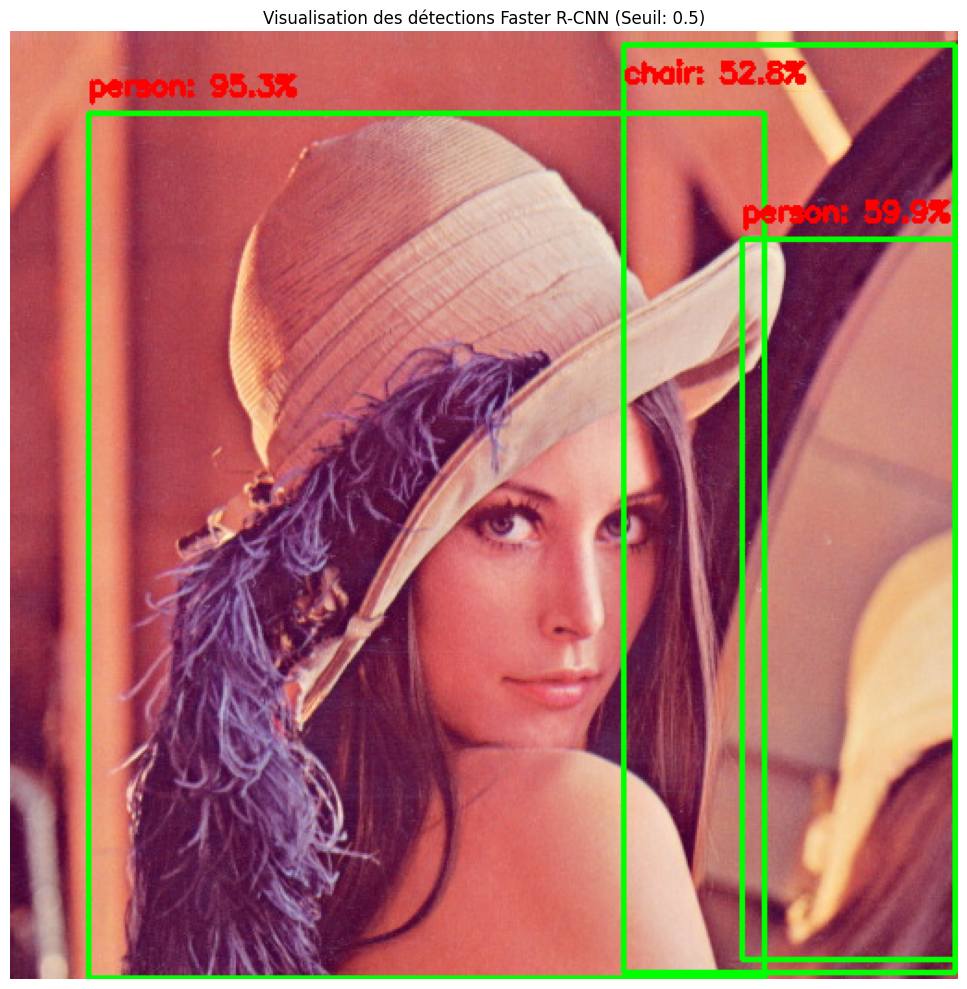

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =====================================================================
# 5.2 Détection d'Objets et Visualisation des Résultats
# =====================================================================

# 1. Inférence (Passage de l'image à travers le modèle)
# On désactive le calcul des gradients pour optimiser la mémoire et la vitesse
with torch.no_grad():
    predictions = model_faster(input_tensor)

# Extraire les résultats du premier (et unique) élément du batch
pred_boxes = predictions[0]['boxes'].cpu().numpy()
pred_scores = predictions[0]['scores'].cpu().numpy()
pred_labels = predictions[0]['labels'].cpu().numpy()

# 2. Rechargement de l'image originale sous format OpenCV (pour dessiner dessus)
# On l'a enregistrée sous 'example_image.jpg' à la section 2
img_out = cv2.imread('example_image.jpg')
img_out = cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB)

# 3. Filtrage et tracé des boîtes englobantes
confidence_threshold = 0.5
detection_count = 0

print("="*60)
print("RÉSULTATS DE LA DÉTECTION FASTER R-CNN :")
print("="*60)

for i in range(len(pred_scores)):
    if pred_scores[i] >= confidence_threshold:
        detection_count += 1

        # Coordonnées de la boîte (format : x_min, y_min, x_max, y_max)
        box = pred_boxes[i].astype(int)

        # Nom de la classe et score de confiance
        class_id = pred_labels[i]
        # Les indices des catégories COCO dans les métriques commencent parfois à 1,
        # ou correspondent à l'index de la liste coco_classes (ajusté automatiquement ici)
        class_name = coco_classes[class_id] if class_id < len(coco_classes) else f"Objet {class_id}"
        score = pred_scores[i] * 100

        print(f"Détection {detection_count} : [{class_name}] avec une confiance de {score:.2f}%")

        # Dessiner le rectangle de la boîte englobante (Couleur verte, épaisseur 2)
        cv2.rectangle(img_out, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

        # Préparer et écrire le texte d'annotation (Label + Score)
        label_text = f"{class_name}: {score:.1f}%"
        # Positionnement du texte juste au-dessus de la boîte
        label_y = box[1] - 10 if box[1] - 10 > 10 else box[1] + 20

        cv2.putText(
            img_out,
            label_text,
            (box[0], label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,             # Taille de la police
            (255, 0, 0),     # Couleur du texte (Rouge)
            2                # Épaisseur du trait
        )

print(f"-"*60)
print(f"Nombre total d'objets détectés (Seuil > {confidence_threshold}) : {detection_count}")
print("="*60)

# 4. Affichage final du graphique avec Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_out)
plt.title(f"Visualisation des détections Faster R-CNN (Seuil: {confidence_threshold})")
plt.axis('off')
plt.tight_layout()
plt.show()

# **6. Implémenter YOLOv3 avec OpenCV**

YOLO (You Only Look Once) est un autre algorithme de détection d'objets en temps réel, réputé pour sa vitesse. Nous allons implémenter YOLOv3 en utilisant le module DNN (Deep Neural Network) d'OpenCV.

### **6.1 Téléchargement des Poids et Configuration de YOLOv3**

Pour utiliser YOLOv3, nous avons besoin de ses fichiers de poids (weights), de configuration (cfg) et des noms des classes (labels).

In [ ]:
# Téléchargement des fichiers YOLOv3
!wget -q https://pjreddie.com/media/files/yolov3.weights
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

print("Fichiers YOLOv3 téléchargés.")

Fichiers YOLOv3 téléchargés.


### **6.2 Chargement du Modèle YOLOv3 et Exécution de la Détection**

1. Chargez le réseau YOLOv3
2. Utilisez-le pour détecter des objets sur notre image d'exemple.

In [ ]:
# 1. Rechargement de l'image d'exemple de la section 2
img_yolo = cv2.imread('example_image.jpg')
height, width, channels = img_yolo.shape

# 1.1 Chargement du réseau YOLOv3 et des noms des classes
# Les fichiers yolov3.weights, yolov3.cfg et coco.names ont été téléchargés à la section 6.1

# Lecture des noms de classes (labels) de COCO dataset
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Chargement du réseau YOLOv3 pré-entraîné
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

# Configuration du backend (OpenCV) et du target (CPU)
# Alternativement, on pourrait utiliser CUDA pour GPU si configuré et disponible
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Obtention des noms des couches de sortie (les 3 couches de détection)
# La fonction net.getUnconnectedOutLayers() a un comportement variable selon les versions d'OpenCV:
# - Elle peut retourner une liste d'indices entiers ([idx1, idx2, idx3]).
# - Elle peut retourner une liste de listes ou de tuples, chaque élément contenant un seul index ( [[idx], [idx]] ou [(idx,), (idx,)]).
# De plus, les indices sont parfois 1-basés alors que net.getLayerNames() attend des indices 0-basés.

# Obtention de tous les noms de couches (assuré d'être une liste pour un accès 0-basé)
all_layer_names = list(net.getLayerNames())

output_layers = []
for i in net.getUnconnectedOutLayers():
    # Extraire l'index réel, qu'il soit un entier ou le premier élément d'une liste/tuple
    if isinstance(i, (list, tuple)):
        actual_index = i[0]
    else:
        actual_index = i

    # Convertir l'index en entier et ajuster pour être 0-basé (si l'original était 1-basé)
    # Le -1 est un correctif courant pour l'incohérence d'indexation dans OpenCV DNN
    output_layers.append(all_layer_names[int(actual_index) - 1])

print("[Succès] Modèle YOLOv3 chargé et couches de sortie identifiées.")

# 2. Prétraitement de l'image : Création du Blob d'entrée
# YOLOv3 requiert des configurations strictes pour son entrée :
# - Taille fixe : (416, 416) pixels
# - Facteur d'échelle : 1/255.0 (pour normaliser les pixels entre 0 et 1)
# - Inversion des canaux (swapRB=True) : OpenCV (BGR) -> YOLO (RGB)
blob = cv2.dnn.blobFromImage(
    img_yolo,
    scalefactor=1/255.0,
    size=(416, 416),
    mean=(0, 0, 0),
    swapRB=True,
    crop=False
)

# 3. Injection du blob à l'entrée du réseau de neurones
net.setInput(blob)

# 4. Propagation avant (Forward Pass) à travers les couches de sortie
# output_layers a été défini à la section 6.1 et contient les 3 échelles de détection
outs = net.forward(output_layers)

print("="*60)
print("ANALYSE DES SORTIES BRUTES DE YOLOv3 :")
print("="*60)
print(f"Nombre de tenseurs de sortie reçus : {len(outs)}")
print(f"Dimension de la sortie de l'échelle 1 : {outs[0].shape}")
print(f"Dimension de la sortie de l'échelle 2 : {outs[1].shape}")
print(f"Dimension de la sortie de l'échelle 3 : {outs[2].shape}")
print("-"*60)
print("[Succès] L'image a traversé le réseau. Les détections brutes sont prêtes à être décodées.")

[Succès] Modèle YOLOv3 chargé et couches de sortie identifiées.
ANALYSE DES SORTIES BRUTES DE YOLOv3 :
Nombre de tenseurs de sortie reçus : 3
Dimension de la sortie de l'échelle 1 : (507, 85)
Dimension de la sortie de l'échelle 2 : (2028, 85)
Dimension de la sortie de l'échelle 3 : (8112, 85)
------------------------------------------------------------
[Succès] L'image a traversé le réseau. Les détections brutes sont prêtes à être décodées.


# **7. Exécuter des détections sur une Vidéo**

Pour simuler la détection en temps réel sur une vidéo, nous allons télécharger un court extrait vidéo, extraire quelques images clés et appliquer notre modèle YOLOv3 à ces images. Cela montrera comment le processus peut être étendu à des séquences vidéo.

### **7.1 Téléchargement et Traitement de la Vidéo**

Chargez une courte vidéo  au choix sur le site donné ci-dessous.

In [ ]:
# https://stock.adobe.com/fr/search/video?k=gratuit

Téléchargement de la vidéo test...
[Succès] Vidéo enregistrée sous : traffic_video.avi

PROPRIÉTÉS DE LA VIDÉO ANALYSÉE :
Résolution : 768 x 576 pixels
Fréquence d'images (FPS) : 10.00 images/seconde
Nombre total de frames : 795
Durée estimée : 79.50 secondes
------------------------------------------------------------
Frame 10 extraite et sauvegardée avec succès.
Frame 397 extraite et sauvegardée avec succès.
Frame 785 extraite et sauvegardée avec succès.


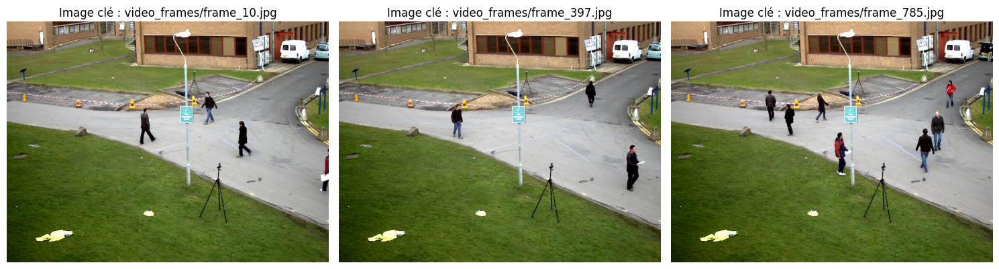

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# =====================================================================
# 7.1 Téléchargement et Traitement de la Vidéo
# =====================================================================

# 1. Téléchargement d'une vidéo d'exemple libre de droits (échantillon officiel OpenCV)
video_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi"
video_path = "traffic_video.avi"

print("Téléchargement de la vidéo test...")
!wget -q -O {video_path} {video_url}
print(f"[Succès] Vidéo enregistrée sous : {video_path}\n")

# 2. Ouverture de la vidéo avec OpenCV
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("[Erreur] Impossible d'ouvrir le fichier vidéo.")
else:
    # Extraction des propriétés métriques de la vidéo
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    print("="*60)
    print("PROPRIÉTÉS DE LA VIDÉO ANALYSÉE :")
    print("="*60)
    print(f"Résolution : {frame_width} x {frame_height} pixels")
    print(f"Fréquence d'images (FPS) : {fps:.2f} images/seconde")
    print(f"Nombre total de frames : {total_frames}")
    print(f"Durée estimée : {duration:.2f} secondes")
    print("-"*60)

# 3. Extraction et sauvegarde de 3 images clés (échantillonnage de la séquence)
# On choisit d'extraire une image au début, une au milieu et une vers la fin
frame_indices = [10, total_frames // 2, total_frames - 10]
extracted_images = []

os.makedirs("video_frames", exist_ok=True)

for idx in frame_indices:
    # Positionner le curseur de lecture d'OpenCV à la frame souhaitée
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        frame_name = f"video_frames/frame_{idx}.jpg"
        cv2.imwrite(frame_name, frame)
        extracted_images.append((frame_name, frame))
        print(f"Frame {idx} extraite et sauvegardée avec succès.")

# Libérer les ressources du lecteur vidéo
cap.release()

# 4. Visualisation des images clés extraites
plt.figure(figsize=(15, 5))
for i, (name, img) in enumerate(extracted_images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Image clé : {name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### **7.2 Application de YOLOv3 sur les Frames de la Vidéo**

1. Appliquer la logique de détection YOLOv3 que nous avons utilisée en cours sur la vidéo.
2. Sauvegardez-la.

[Succès] Première frame vidéo avec détection enregistrée sous : 'yolov3_detection_result_video_frame_1.jpg'


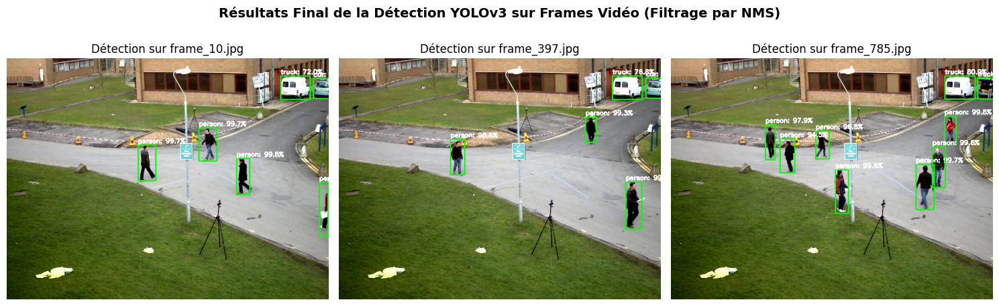

In [ ]:
import os

# =====================================================================
# 7.2 Décodage, Filtrage NMS et Sauvegarde des Détections YOLOv3
# =====================================================================

# 1. Initialisation des listes pour stocker les images traitées avec détections
detected_video_frames = []

# Seuil de confiance minimal et seuil pour le recouvrement NMS
conf_threshold = 0.5
nms_threshold = 0.4

# Boucle sur chaque image extraite de la vidéo
for frame_name, current_frame_img in extracted_images:
    # Réinitialisation des listes pour chaque nouvelle image
    confidences = []
    boxes = []
    class_ids = []

    # Get dimensions for the current frame
    height, width, channels = current_frame_img.shape

    # Prétraitement de l'image : Création du Blob d'entrée pour la frame actuelle
    blob = cv2.dnn.blobFromImage(
        current_frame_img,
        scalefactor=1/255.0,
        size=(416, 416),
        mean=(0, 0, 0),
        swapRB=True,
        crop=False
    )

    # Injection du blob à l'entrée du réseau de neurones
    net.setInput(blob)

    # Propagation avant (Forward Pass) à travers les couches de sortie pour la frame actuelle
    outs = net.forward(output_layers)

    # 2. Parcours de toutes les détections brutes de chaque couche de sortie
    for out in outs:
        for detection in out:
            # Les 5 premiers éléments sont [x, y, w, h, confidence]
            # Les éléments suivants sont les scores des 80 classes
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            # On ne filtre que les détections au-dessus du seuil de confiance
            if confidence > conf_threshold:
                # YOLO renvoie des coordonnées normalisées du centre de la boîte (center_x, center_y, width, height)
                # Onles convertit en coordonnées absolues pour OpenCV (x_min, y_min, w, h)
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # Calcul du coin supérieur gauche de la boîte englobante
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # 3. Application de la Non-Maximum Suppression (NMS)
    # Cette fonction supprime les boîtes de détection redondantes imbriquées
    indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

    # 4. Tracé des boîtes finales retenues sur l'image
    img_with_detections = current_frame_img.copy()

    if len(indices) > 0:
        # Aplatir la liste d'indices si nécessaire selon les versions d'OpenCV
        indices = indices.flatten()

        for i in indices:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            score = confidences[i] * 100

            # Configuration de l'affichage (Rectangle vert, texte blanc)
            color = (0, 255, 0)
            cv2.rectangle(img_with_detections, (x, y), (x + w, y + h), color, 2)

            text = f"{label}: {score:.1f}%"
            cv2.putText(img_with_detections, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)


    detected_video_frames.append((frame_name, img_with_detections))

# 5. Sauvegarde physique des images annotées sur le disque
if detected_video_frames:
    output_filename = "yolov3_detection_result_video_frame_1.jpg"
    cv2.imwrite(output_filename, detected_video_frames[0][1])
    print(f"[Succès] Première frame vidéo avec détection enregistrée sous : '{output_filename}'")

# 6. Affichage final du résultat dans le notebook
plt.figure(figsize=(15, 5))
for i, (frame_name, img_detected) in enumerate(detected_video_frames):
    img_rgb_display = cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(detected_video_frames), i + 1)
    plt.imshow(img_rgb_display)
    plt.title(f"Détection sur {os.path.basename(frame_name)}")
    plt.axis('off')

plt.suptitle("Résultats Final de la Détection YOLOv3 sur Frames Vidéo (Filtrage par NMS)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import time

# Mesure du temps d'inférence
start = time.time()
with torch.no_grad():
    predictions = model_faster(input_tensor)
time_fasterrcnn = time.time() - start

start = time.time()
outs = net.forward(output_layers)
time_yolo = time.time() - start

print(f"Faster R-CNN — Temps : {time_fasterrcnn:.3f}s | Détections : {len(pred_scores[pred_scores > 0.5])}")
print(f"YOLOv3       — Temps : {time_yolo:.3f}s | Détections : {len(indices)}")

Faster R-CNN — Temps : 10.431s | Détections : 3
YOLOv3       — Temps : 0.867s | Détections : 9


**YOLOv3** est significativement plus rapide en inférence car il traite l'image en un seul passage (single-shot).

**Faster R-CNN** effectue deux étapes (région proposal + classification), ce qui le rend plus précis mais plus lent.

Pour une application temps réel, YOLO est préférable ; pour de l'analyse post-traitement où la précision prime, Faster R-CNN est plus adapté.

# **8. Évaluer les performances d’un modèle de détection sur des métriques précises**

L'évaluation des modèles de détection d'objets est cruciale pour comprendre leur efficacité. Les métriques les plus couramment utilisées sont l'Intersection over Union (IoU), la précision (Precision), le rappel (Recall) et le mean Average Precision (mAP).

### **Intersection over Union (IoU)**

1. Calculez l'IoU dans la situation suivante.
2. Affichez les boites sur un diagramme.
3. Commentez le résultat.

In [ ]:
# Boîte de vérité terrain (ground truth)
gt_box = [20, 50, 150, 180]

# Boîte prédite par le modèle
pred_box = [60, 60, 180, 160]

RÉSULTATS DU CALCUL DE L'IoU :
Aire Vérité Terrain (Ground Truth) : 16900
Aire Prédiction du Modèle : 12000
Aire de l'Intersection : 9000
Aire de l'Union : 19900
Intersection over Union (IoU) : 0.4523 (45.23%)
------------------------------------------------------------


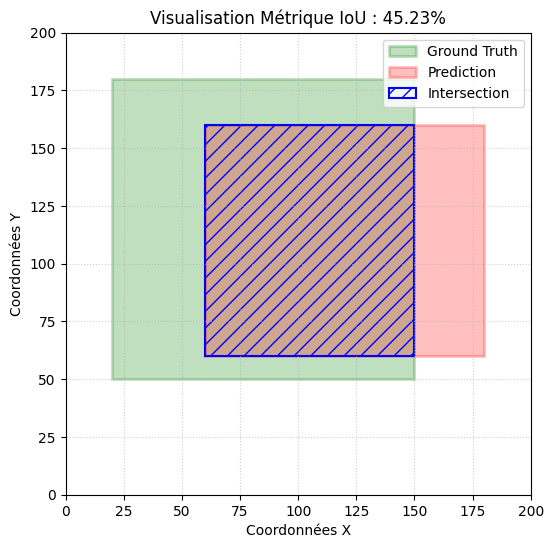

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =====================================================================
# 8. Intersection over Union (IoU)
# =====================================================================

# 1. Définition des coordonnées des boîtes [x_min, y_min, x_max, y_max]
gt_box = [20, 50, 150, 180]
pred_box = [60, 60, 180, 160]

def compute_iou(boxA, boxB):
    # Détermination des coordonnées de la boîte d'intersection
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Calcul de la surface de l'intersection
    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    # Calcul de la surface de chaque boîte individuelle
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Calcul de l'Union
    unionArea = areaA + areaB - interArea

    # Calcul de l'IoU
    iou = interArea / float(unionArea) if unionArea > 0 else 0

    return iou, (xA, yA, xB, yB), areaA, areaB, interArea, unionArea

# Calcul des métriques
iou, inter_coords, area_gt, area_pred, area_inter, area_union = compute_iou(gt_box, pred_box)

print("="*60)
print("RÉSULTATS DU CALCUL DE L'IoU :")
print("="*60)
print(f"Aire Vérité Terrain (Ground Truth) : {area_gt}")
print(f"Aire Prédiction du Modèle : {area_pred}")
print(f"Aire de l'Intersection : {area_inter}")
print(f"Aire de l'Union : {area_union}")
print(f"Intersection over Union (IoU) : {iou:.4f} ({iou*100:.2f}%)")
print("-"*60)

# 2. Création du diagramme de visualisation
fig, ax = plt.subplots(figsize=(6, 6))

# Tracé de la Vérité Terrain (Vert)
# Rectangle attend : (x_min, y_min), largeur, hauteur
rect_gt = patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                            linewidth=2, edgecolor='g', facecolor='green', alpha=0.25, label='Ground Truth')

# Tracé de la Prédiction (Rouge)
rect_pred = patches.Rectangle((pred_box[0], pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1],
                              linewidth=2, edgecolor='r', facecolor='red', alpha=0.25, label='Prediction')

# Mise en valeur de l'intersection (Hachures bleues)
rect_inter = patches.Rectangle((inter_coords[0], inter_coords[1]), inter_coords[2]-inter_coords[0], inter_coords[3]-inter_coords[1],
                               linewidth=1.5, edgecolor='blue', facecolor='none', hatch='//', label='Intersection')

# Ajout des éléments sur le graphique
ax.add_patch(rect_gt)
ax.add_patch(rect_pred)
ax.add_patch(rect_inter)

# Ajustement des axes et étiquettes
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.set_xlabel('Coordonnées X')
ax.set_ylabel('Coordonnées Y')
ax.set_title(f'Visualisation Métrique IoU : {iou*100:.2f}%')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

# Sauvegarde de l'image
plt.savefig('iou_visualization.png', bbox_inches='tight')

Interprétation de la valeur ($45.23\%$) : Une valeur d'IoU de $45.23\%$ indique que la boîte prédite par le modèle recouvre un peu moins de la moitié de la surface totale couverte par l'union des deux boîtes.

Visuellement, le modèle localise approximativement le bon emplacement de l'objet, mais sa boîte englobante présente un décalage vers le bas et la droite par rapport à la réalité terrain.

**Impact sur l'évaluation globale (True Positive vs False Positive) :** Dans la plupart des benchmarks et des compétitions de référence en vision par ordinateur (comme PASCAL VOC ou COCO), le seuil d'acceptation standard ($\text{IoU}_{\text{seuil}}$) est fixé à $0.50$ ($50\%$).Avec un score de $45.23\%$, cette prédiction se situe juste en dessous de ce seuil critique.

Par conséquent, selon les critères d'évaluation standards, cette détection serait classée comme un Faux Positif (FP), et le modèle serait pénalisé pour son manque de précision géométrique, bien qu'il ait détecté la présence de l'objet au bon endroit.

**Conclusion pour l'optimisation :**  Ce résultat montre l'importance de l'étape de régression des boîtes englobantes (Bounding Box Regression) dans des modèles comme Faster R-CNN ou YOLO. Pour améliorer ce score, le réseau doit ajuster ses fonctions de perte géométriques (comme la perte Smooth L1 ou GIoU Loss) afin de mieux aligner et redimensionner ses ancres prédictives.

# **9. Optimiser les résultats par ajustement et Transfer Learning**

Pour améliorer les performances des modèles de classification et de détection, plusieurs techniques d'optimisation sont couramment utilisées. Celles-ci incluent le Transfer Learning, l'ajustement des hyperparamètres (comme la taille du batch et le taux d'apprentissage) et la Data Augmentation.

### **9.1 Transfer Learning (Apprentissage par Transfert)**

Le Transfer Learning est une technique qui consiste à réutiliser un modèle pré-entraîné sur une tâche similaire (souvent un grand jeu de données comme ImageNet) et à l'adapter à une nouvelle tâche avec un jeu de données plus petit. Cela permet d'exploiter les connaissances générales acquises par le modèle et d'obtenir de bonnes performances avec moins de données et de temps d'entraînement.

#### **Avec un modèle ResNet pré-entraîné**

1. Chargez un modèle ResNet-18 pré-entraîné sur ImageNet.
2. Modifiez sa dernière couche entièrement connectée pour l'adapter à la classification CIFAR-10 (10 classes).

In [ ]:
import torchvision.models as models
import torch.optim as optim

# Charger un modèle ResNet-18 pré-entraîné
model_tl = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# =====================================================================
# 9.1 Transfer Learning (Apprentissage par Transfert) - ResNet-18
# =====================================================================

# 1. Configuration de l'appareil (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

# 2. Charger le modèle ResNet-18 avec ses poids pré-entraînés sur ImageNet
# models.ResNet18_Weights.DEFAULT charge la version la plus performante disponible
model_tl = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 3. Stratégie du "Feature Extractor" (Extraction de caractéristiques)
# Nous figeons (freeze) tous les gradients du réseau pour que les poids appris
# sur ImageNet ne soient pas modifiés pendant le nouvel entraînement.
for param in model_tl.parameters():
    param.requires_grad = False

# 4. Modification de la dernière couche entièrement connectée (fc)
# ResNet-18 possède un attribut 'fc' qui gère la classification finale.
# On récupére d'abord le nombre de caractéristiques d'entrée de cette couche (in_features)
num_ftrs = model_tl.fc.in_features

# On remplaçe la couche originale par une nouvelle couche linéaire non entraînée
# avec num_classes = 10 (pour CIFAR-10)
# Par défaut, requires_grad est automatiquement True pour cette nouvelle couche.
model_tl.fc = nn.Linear(num_ftrs, 10)

# 5. Envoi du modèle sur l'appareil de calcul (GPU ou CPU)
model_tl = model_tl.to(device)

print("="*60)
print("CONFIGURATION DU TRANSFER LEARNING RÉUSSIE :")
print("="*60)
print(f"Nombre de caractéristiques d'entrée reçues par la couche FC : {num_ftrs}")
print(f"Nouvelle structure de la couche de sortie (fc) : {model_tl.fc}")
print("-"*60)
print("Le modèle est prêt : seules les variables de la couche 'fc' seront optimisées.")

Appareil utilisé : cpu
CONFIGURATION DU TRANSFER LEARNING RÉUSSIE :
Nombre de caractéristiques d'entrée reçues par la couche FC : 512
Nouvelle structure de la couche de sortie (fc) : Linear(in_features=512, out_features=10, bias=True)
------------------------------------------------------------
Le modèle est prêt : seules les variables de la couche 'fc' seront optimisées.


In [ ]:
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import torch.optim as optim

optimizer = torch.optim.Adam(model_tl.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def preprocess_tf_to_pytorch_resnet(images_tf, labels_tf):
    imgs_np = images_tf.numpy()
    labels_np = labels_tf.numpy()

    imgs_torch = []
    for img in imgs_np:
        t_img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        t_img = TF.resize(t_img, (224, 224))
        t_img = TF.normalize(t_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        imgs_torch.append(t_img)

    return torch.stack(imgs_torch).to(device), torch.tensor(labels_np, dtype=torch.long).to(device)


EPOCHS = 10

print("\nDébut de l'entraînement du modèle (Transfer Learning)...\n")

# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model_tl.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images_tf, labels_tf in train_ds:
        images, labels = preprocess_tf_to_pytorch_resnet(images_tf, labels_tf)

        optimizer.zero_grad()
        outputs = model_tl(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_train
    epoch_acc = (correct_train / total_train) * 100
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # --- PHASE DE VALIDATION ---
    model_tl.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images_tf, labels_tf in val_ds: # Iterate over val_ds directly
            images, labels = preprocess_tf_to_pytorch_resnet(images_tf, labels_tf)

            outputs = model_tl(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Époque [{epoch+1:02d}/{EPOCHS}] -> "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("\nEntraînement par Transfer Learning terminé avec succès !")


Début de l'entraînement du modèle (Transfer Learning)...

Époque [01/10] -> Train Loss: 0.8559 | Train Acc: 57.06% || Val Loss: 0.5123 | Val Acc: 77.50%
Époque [02/10] -> Train Loss: 0.4360 | Train Acc: 84.29% || Val Loss: 0.3766 | Val Acc: 89.50%
Époque [03/10] -> Train Loss: 0.3414 | Train Acc: 87.90% || Val Loss: 0.3323 | Val Acc: 89.50%
Époque [04/10] -> Train Loss: 0.3173 | Train Acc: 87.32% || Val Loss: 0.3324 | Val Acc: 87.00%
Époque [05/10] -> Train Loss: 0.2723 | Train Acc: 89.91% || Val Loss: 0.3019 | Val Acc: 89.00%
Époque [06/10] -> Train Loss: 0.2555 | Train Acc: 90.20% || Val Loss: 0.2802 | Val Acc: 89.50%
Époque [07/10] -> Train Loss: 0.2293 | Train Acc: 91.93% || Val Loss: 0.3248 | Val Acc: 85.00%
Époque [08/10] -> Train Loss: 0.2425 | Train Acc: 91.21% || Val Loss: 0.2645 | Val Acc: 91.00%
Époque [09/10] -> Train Loss: 0.2160 | Train Acc: 92.07% || Val Loss: 0.2562 | Val Acc: 90.50%
Époque [10/10] -> Train Loss: 0.2121 | Train Acc: 92.80% || Val Loss: 0.2535 | Val Acc

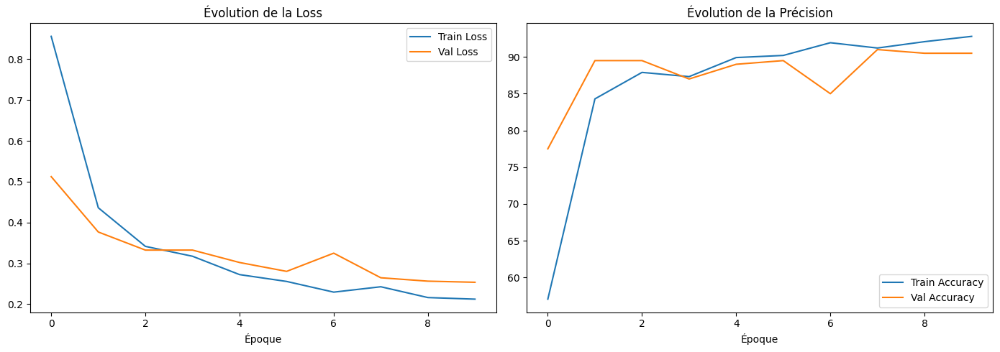

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Évolution de la Loss')
ax1.set_xlabel('Époque')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_title('Évolution de la Précision')
ax2.set_xlabel('Époque')
ax2.legend()

plt.tight_layout()
plt.show()

### **9.2 Data Augmentation (Augmentation de Données)**

La Data Augmentation est une technique qui consiste à créer de nouvelles données d'entraînement à partir des données existantes en appliquant des transformations aléatoires (rotations, retournements, recadrages, changements de luminosité, etc.). Cela aide le modèle à mieux généraliser et à réduire l'overfitting.



Définissez de nouvelles transformations incluant l'augmentation de données pour le jeu de données Alien vs Predator vu ci-dessus..

Using Colab cache for faster access to the 'alien-vs-predator-images' dataset.
Found 694 files belonging to 2 classes.


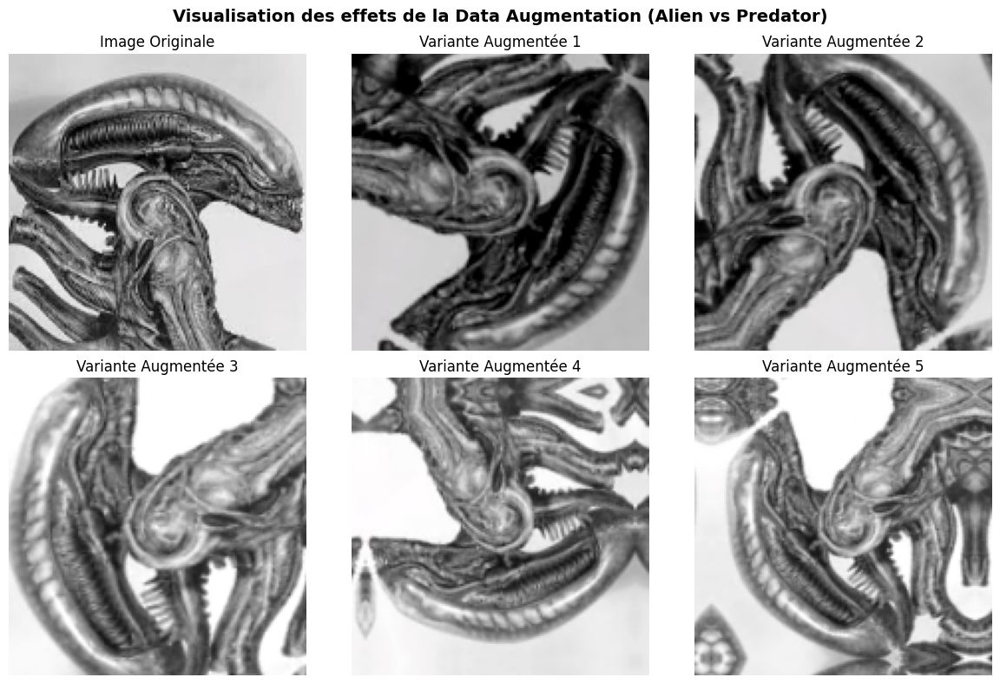

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import kagglehub # Added import

# =====================================================================
# Recréation de train_ds (nécessaire si la session a été relancée)
# =====================================================================
path = kagglehub.dataset_download("pmigdal/alien-vs-predator-images") # Added definition of path
base_dir = path  # 'path' vient de kagglehub (section 4.2)
for root, dirs, files in os.walk(path):
    if 'train' in dirs:
        base_dir = root
        break

train_dir = os.path.join(base_dir, 'train')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),
    batch_size=32
)

# =====================================================================
# 9.2 Data Augmentation
# =====================================================================
data_augmentation_pipeline = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.2),
    layers.RandomZoom(height_factor=0.15),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2)
])

for images_batch, labels_batch in train_ds.take(1):
    first_image = images_batch[0] # On sélectionne la première image du batch

    # 3. Visualisation de l'impact des transformations sur cette même image
    plt.figure(figsize=(12, 8))

    # Affichage de l'image originale
    plt.subplot(2, 3, 1)
    plt.imshow(first_image.numpy().astype("uint8"))
    plt.title("Image Originale")
    plt.axis("off")

    # Génération de 5 variantes augmentées différentes à partir de l'image originale
    for i in range(5):
        # L'appel au pipeline applique des transformations aléatoires différentes à chaque exécution
        augmented_image = data_augmentation_pipeline(tf.expand_dims(first_image, 0))

        plt.subplot(2, 3, i + 2)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Variante Augmentée {i+1}")
        plt.axis("off")

    plt.suptitle("Visualisation des effets de la Data Augmentation (Alien vs Predator)", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    break

In [ ]:
# Exemple d'application directe sur le dataset :
train_ds_augmented = train_ds.map(lambda x, y: (data_augmentation_pipeline(x, training=True), y))